## Mesure de la distribution des classes

In [2]:
import pandas as pd

df = pd.read_csv("data_clean/train_clean.csv")

#### distribution des classes

In [3]:
# distribution
class_counts = df["Response"].value_counts().sort_index()

print(class_counts)

Response
1.0     6207
2.0     6552
3.0     1013
4.0     1428
5.0     5432
6.0    11233
7.0     8027
8.0    19489
Name: count, dtype: int64


In [4]:
# proportion
class_ratio = df["Response"].value_counts(normalize=True).sort_index()
print(class_ratio)

Response
1.0    0.104528
2.0    0.110338
3.0    0.017059
4.0    0.024048
5.0    0.091477
6.0    0.189168
7.0    0.135178
8.0    0.328203
Name: proportion, dtype: float64


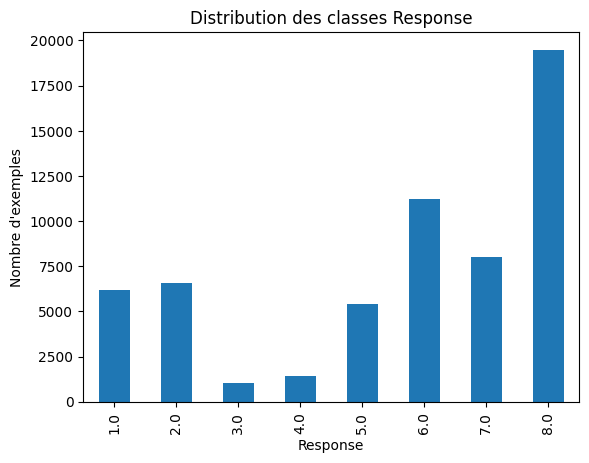

In [5]:
# graphe
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Distribution des classes Response")
plt.xlabel("Response")
plt.ylabel("Nombre d'exemples")

plt.show()

### classe majoritaire

In [6]:
max_class_size = class_counts.max()
print("Classe majoritaire :", max_class_size)

Classe majoritaire : 19489


### classe rare

In [9]:
rare_classes = class_counts[class_counts < max_class_size * (1/3)]
print("Classes rares :")
print(rare_classes)

Classes rares :
Response
1.0    6207
3.0    1013
4.0    1428
5.0    5432
Name: count, dtype: int64


## STRATÉGIE A
Générer seulement pour les classes rares

In [10]:
max_size = class_counts.max()

gen_A = {}

for cls, count in class_counts.items():
    if count < max_size * 0.5:
        gen_A[cls] = int(max_size * 0.5 - count)
    else:
        gen_A[cls] = 0

print("Generation plan A (classes rares)")
print(gen_A)

Generation plan A (classes rares)
{1.0: 3537, 2.0: 3192, 3.0: 8731, 4.0: 8316, 5.0: 4312, 6.0: 0, 7.0: 1717, 8.0: 0}


## STRATÉGIE B
Équilibrage complet

In [11]:
gen_B = {}

for cls, count in class_counts.items():
    gen_B[cls] = max_size - count

print("Generation plan B (equilibrage complet)")
print(gen_B)

Generation plan B (equilibrage complet)
{1.0: 13282, 2.0: 12937, 3.0: 18476, 4.0: 18061, 5.0: 14057, 6.0: 8256, 7.0: 11462, 8.0: 0}
